# IMPORTS

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [105]:
data_dir = Path("..") / "data"

df1 = pd.read_csv(data_dir / "neo.csv")
df2 = pd.read_csv(data_dir / "neo_v2.csv")

print(df1.shape)
print(df2.shape)
print(df1.equals(df2))

(90836, 10)
(90836, 10)
True


A zatem te dwa zbiory z kaggla sa identico

In [106]:
df = pd.read_csv(data_dir / "neo_v2.csv")

# EDA

In [107]:
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [108]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  str    
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  str    
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), str(2)
memory usage: 5.7 MB


In [109]:
df.describe()

,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,9.083600e+04,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,1.438288e+07,0.127432,0.284947,48066.918918,3.706655e+07,23.527103
std,2.087202e+07,0.298511,0.667491,25293.296961,2.235204e+07,2.894086
min,2.000433e+06,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,3.448110e+06,0.019256,0.043057,28619.020645,1.721082e+07,21.340000
50%,3.748362e+06,0.048368,0.108153,44190.117890,3.784658e+07,23.700000
75%,3.884023e+06,0.143402,0.320656,62923.604633,5.654900e+07,25.700000
max,5.427591e+07,37.892650,84.730541,236990.128088,7.479865e+07,33.200000


Nie ma żadnych nulli ani missing values, id i name najsensowniej usunac w pozniejszej fazie

In [110]:
print(df["orbiting_body"].unique())

<StringArray>
['Earth']
Length: 1, dtype: str


In [111]:
print(df["sentry_object"].unique())

[False]


Czyli te informacje beda bezuzyteczne dla modelu, poniewaz kazdy rekord ja ma w tej samej postaci ( value )

In [112]:
df = df.drop(["id", "name", "orbiting_body", "sentry_object"], axis=1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   est_diameter_min    90836 non-null  float64
 1   est_diameter_max    90836 non-null  float64
 2   relative_velocity   90836 non-null  float64
 3   miss_distance       90836 non-null  float64
 4   absolute_magnitude  90836 non-null  float64
 5   hazardous           90836 non-null  bool   
dtypes: bool(1), float64(5)
memory usage: 3.6 MB


/tmp/ipykernel_162104/4163545985.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hazardous_counts.index, y=hazardous_counts.values, palette='viridis')


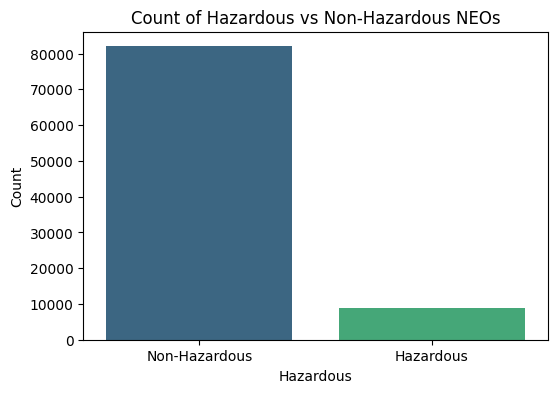

In [113]:
hazardous_counts = df["hazardous"].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=hazardous_counts.index, y=hazardous_counts.values, palette="viridis")
plt.title("Count of Hazardous vs Non-Hazardous NEOs")
plt.xlabel("Hazardous")
plt.ylabel("Count")
plt.xticks([0, 1], ["Non-Hazardous", "Hazardous"])
plt.show()

In [114]:
print(f"Hazardous NEOs: {hazardous_counts[True]}")
print(f"Non-Hazardous NEOs: {hazardous_counts[False]}")
print(
    f"Percentage of Hazardous NEOs: {hazardous_counts[True] / (hazardous_counts[True] + hazardous_counts[False]) * 100:.2f}%"
)

Hazardous NEOs: 8840
Non-Hazardous NEOs: 81996
Percentage of Hazardous NEOs: 9.73%


Jak widać jest bardzo duży imbalance klas, będzie trzeba skupić na tym uwage przy tworzeniu modelu i jego ewaluacji

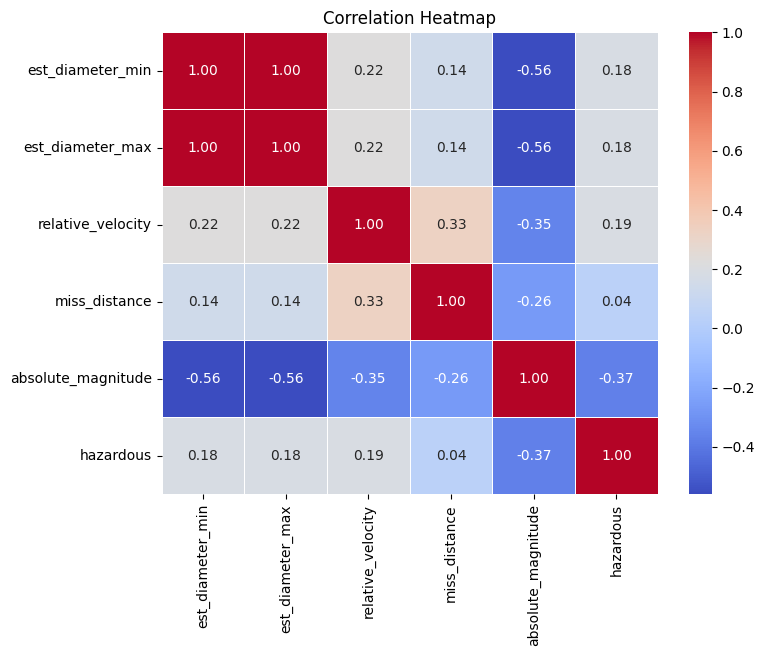

In [115]:
df_corr = df.copy()
df_corr["hazardous"] = df_corr["hazardous"].astype(int)
corr = df_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

A zatem usuwamy również jedną z [est_diameter_min, est_diameter_max] z powodu ich idealnej korelacji liniowej